<img style="float: center;" src='https://github.com/STScI-MIRI/MRS-ExampleNB/raw/main/assets/banner1.png' alt="stsci_logo" width="900px"/> 

<a id="title_ID"></a>
# Get MRS channels apertures with Pysiaf

**Goal:** Get information about MRS apertures using the pysiaf package: https://pysiaf.readthedocs.io/en/latest/

**Author:** Boris Trahin, MIRI MRS team

**Last updated:** July 14th, 2025

***
## Get MRS apertures

In [1]:
import pysiaf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Define a color for each channel
color_map = {
    'CHANNEL1': "#3DB6E2FF",
    'CHANNEL2': "#61975BFF",
    'CHANNEL3': "#C9F018FF",
    'CHANNEL4': "#E82A2AFF",
}

In [3]:
instrument = 'MIRI'
siaf = pysiaf.Siaf(instrument)

In [4]:
# print the names of all MIRI apertures
for key in siaf.apertures.keys():
    print(key)

MIRIM_FULL_OSS
MIRIM_FULL
MIRIM_ILLUM
MIRIM_BRIGHTSKY
MIRIM_SUB256
MIRIM_SUB128
MIRIM_SUB64
MIRIM_SLITLESSPRISM
MIRIM_SLITLESSUPPER
MIRIM_SLITLESSLOWER
MIRIM_MASK1065
MIRIM_MASK1140
MIRIM_MASK1550
MIRIM_MASKLYOT
MIRIM_FULL1065
MIRIM_FULL1140
MIRIM_FULL1550
MIRIM_FULLLYOT
MIRIM_TAMRS
MIRIM_TALRS
MIRIM_TABLOCK
MIRIM_TALYOT_UL
MIRIM_TALYOT_UR
MIRIM_TALYOT_LL
MIRIM_TALYOT_LR
MIRIM_TALYOT_CUL
MIRIM_TALYOT_CUR
MIRIM_TALYOT_CLL
MIRIM_TALYOT_CLR
MIRIM_TA1550_UL
MIRIM_TA1550_UR
MIRIM_TA1550_LL
MIRIM_TA1550_LR
MIRIM_TA1550_CUL
MIRIM_TA1550_CUR
MIRIM_TA1550_CLL
MIRIM_TA1550_CLR
MIRIM_TA1140_UL
MIRIM_TA1140_UR
MIRIM_TA1140_LL
MIRIM_TA1140_LR
MIRIM_TA1140_CUL
MIRIM_TA1140_CUR
MIRIM_TA1140_CLL
MIRIM_TA1140_CLR
MIRIM_TA1065_UL
MIRIM_TA1065_UR
MIRIM_TA1065_LL
MIRIM_TA1065_LR
MIRIM_TA1065_CUL
MIRIM_TA1065_CUR
MIRIM_TA1065_CLL
MIRIM_TA1065_CLR
MIRIM_TAFULL
MIRIM_TAILLUM
MIRIM_TABRIGHTSKY
MIRIM_TASUB256
MIRIM_TASUB128
MIRIM_TASUB64
MIRIM_TASLITLESSPRISM
MIRIM_CORON1065
MIRIM_CORON1140
MIRIM_CORON1550
MIR

***
## Plot MRS apertures for each band

In [5]:
mrs_aper_ch = [x for x in siaf.apertures.keys() if 'MIRIFU_CHANNEL' in x]

In [ ]:
# print the aperture attributes
for x in dir(siaf[mrs_aper_ch[0]]):
    if not x.startswith('_'):
        print(x)

JWST MIRI aperture named MIRIFU_CHANNEL1A
(V2,V3) center coordinates: (-503.378, -318.9992) 

JWST MIRI aperture named MIRIFU_CHANNEL1B
(V2,V3) center coordinates: (-503.3306, -319.1144) 

JWST MIRI aperture named MIRIFU_CHANNEL1C
(V2,V3) center coordinates: (-503.2892, -318.8461) 

JWST MIRI aperture named MIRIFU_CHANNEL2A
(V2,V3) center coordinates: (-503.4653, -319.2868) 

JWST MIRI aperture named MIRIFU_CHANNEL2B
(V2,V3) center coordinates: (-503.537, -319.57) 

JWST MIRI aperture named MIRIFU_CHANNEL2C
(V2,V3) center coordinates: (-503.3849, -319.4975) 

JWST MIRI aperture named MIRIFU_CHANNEL3A
(V2,V3) center coordinates: (-504.0324, -319.0009) 

JWST MIRI aperture named MIRIFU_CHANNEL3B
(V2,V3) center coordinates: (-504.0859, -319.1972) 

JWST MIRI aperture named MIRIFU_CHANNEL3C
(V2,V3) center coordinates: (-503.9589, -319.1787) 

JWST MIRI aperture named MIRIFU_CHANNEL4A
(V2,V3) center coordinates: (-502.7341, -319.738) 

JWST MIRI aperture named MIRIFU_CHANNEL4B
(V2,V3) cente

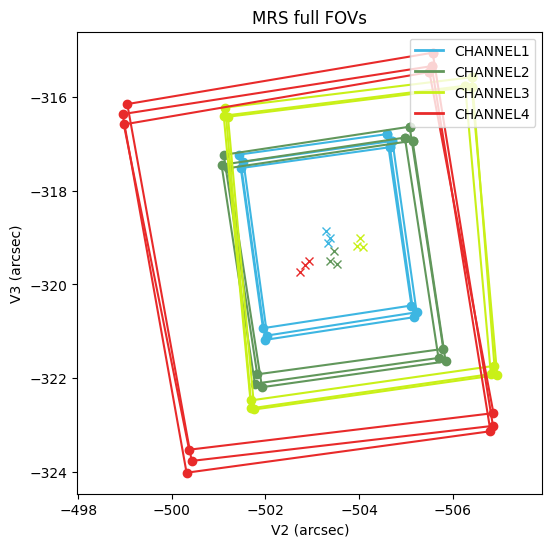

In [6]:
# plot the fov for each band
plt.figure(figsize=(6, 6))
for aper in mrs_aper_ch:
    aperture = siaf[aper]
    # use a different color for each channel
    for channel, color in color_map.items():
        if channel in aper:
            plot_color = color
            break

    # extract the 4 corners
    idl_x = [aperture.XIdlVert1, aperture.XIdlVert2, aperture.XIdlVert3, aperture.XIdlVert4]
    idl_y = [aperture.YIdlVert1, aperture.YIdlVert2, aperture.YIdlVert3, aperture.YIdlVert4]
    v2, v3 = aperture.idl_to_tel(idl_x, idl_y)
    v2 = list(v2) + [v2[0]]
    v3 = list(v3) + [v3[0]]

    v3_center = aperture.V3Ref
    v2_center = aperture.V2Ref

    print(aperture)
    print(f"(V2,V3) center coordinates: {(v2_center,v3_center)} \n")

    plt.plot(v2, v3, marker='o', linestyle='-', color=plot_color, label=aper if aper == mrs_aper_ch[0] else "")
    plt.plot(v2_center, v3_center, marker='x', color=plot_color)

plt.title('MRS full FOVs')
plt.xlabel('V2 (arcsec)')
plt.ylabel('V3 (arcsec)')
plt.axis('equal')
plt.gca().invert_xaxis()

handles = []
labels = []
for channel, color in color_map.items():
    handles.append(plt.Line2D([0], [0], color=color, lw=2))
    labels.append(channel)
plt.legend(handles, labels, loc='upper right')


***
## Plot apertures for each slice of a specific band

JWST MIRI aperture named MIRIFU_2ASLICE01
(V2,V3) center coordinates: (-503.1272, -317.065) 

JWST MIRI aperture named MIRIFU_2ASLICE02
(V2,V3) center coordinates: (-503.1694, -317.3427) 

JWST MIRI aperture named MIRIFU_2ASLICE03
(V2,V3) center coordinates: (-503.2117, -317.6204) 

JWST MIRI aperture named MIRIFU_2ASLICE04
(V2,V3) center coordinates: (-503.254, -317.8982) 

JWST MIRI aperture named MIRIFU_2ASLICE05
(V2,V3) center coordinates: (-503.2962, -318.1759) 

JWST MIRI aperture named MIRIFU_2ASLICE06
(V2,V3) center coordinates: (-503.3385, -318.4536) 

JWST MIRI aperture named MIRIFU_2ASLICE07
(V2,V3) center coordinates: (-503.3808, -318.7313) 

JWST MIRI aperture named MIRIFU_2ASLICE08
(V2,V3) center coordinates: (-503.423, -319.0091) 

JWST MIRI aperture named MIRIFU_2ASLICE09
(V2,V3) center coordinates: (-503.4653, -319.2868) 

JWST MIRI aperture named MIRIFU_2ASLICE10
(V2,V3) center coordinates: (-503.5076, -319.5645) 

JWST MIRI aperture named MIRIFU_2ASLICE11
(V2,V3) cen

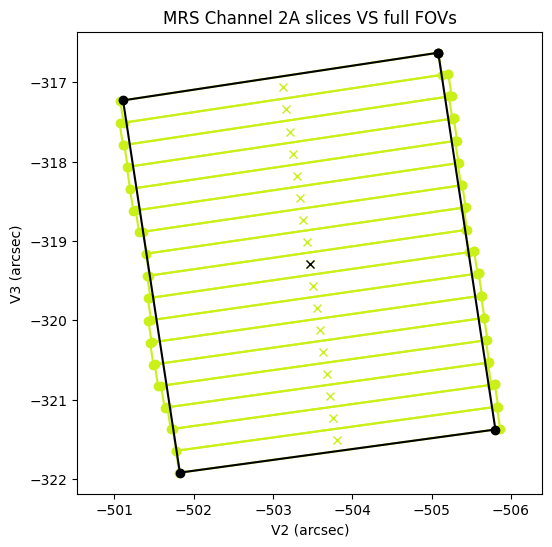

In [7]:
band = '2A'

# plot apertures for each slice of a specific band
mrs_aper_sl = [x for x in siaf.apertures.keys() if f'MIRIFU_{band}' in x]
plt.figure(figsize=(6, 6))
for aper in mrs_aper_sl:
    aperture = siaf[aper]
    plot_color = color_map['CHANNEL3']

    # extract the 4 corners
    idl_x = [aperture.XIdlVert1, aperture.XIdlVert2, aperture.XIdlVert3, aperture.XIdlVert4]
    idl_y = [aperture.YIdlVert1, aperture.YIdlVert2, aperture.YIdlVert3, aperture.YIdlVert4]
    v2, v3 = aperture.idl_to_tel(idl_x, idl_y)
    v2 = list(v2) + [v2[0]]
    v3 = list(v3) + [v3[0]]

    v3_center = aperture.V3Ref
    v2_center = aperture.V2Ref

    print(aperture)
    print(f"(V2,V3) center coordinates: {(v2_center,v3_center)} \n")

    plt.plot(v2, v3, marker='o', linestyle='-', color=plot_color)
    plt.plot(v2_center, v3_center, marker='x', color=plot_color)

# plot the aperture for the specific band
aperture = siaf[f'MIRIFU_CHANNEL{band}']
idl_x = [aperture.XIdlVert1, aperture.XIdlVert2, aperture.XIdlVert3, aperture.XIdlVert4]
idl_y = [aperture.YIdlVert1, aperture.YIdlVert2, aperture.YIdlVert3, aperture.YIdlVert4]
v2, v3 = aperture.idl_to_tel(idl_x, idl_y)
v2 = list(v2) + [v2[0]]
v3 = list(v3) + [v3[0]]
v3_center = aperture.V3Ref
v2_center = aperture.V2Ref

print(aperture)
print(f"(V2,V3) center coordinates: {(v2_center,v3_center)} \n")

plt.plot(v2, v3, marker='o', linestyle='-', color='black', label=aper if aper == mrs_aper_ch[0] else "")
plt.plot(v2_center, v3_center, marker='x', color='black')

plt.title(f'MRS Channel {band} slices VS full FOVs')
plt.xlabel('V2 (arcsec)')
plt.ylabel('V3 (arcsec)')
plt.axis('equal')
plt.gca().invert_xaxis()

In [ ]:
import re
print(mrs_aper_ch)

search_term = '1a'
matches = [item for item in mrs_aper_ch if search_term.lower() in item.lower()]

if matches:
    print("Yes")
    for match in matches:
        print(match)
else:
    print("No")

In [ ]:
for aper in mrs_aper_ch:
    print(aper)
    aperture = siaf[aper]
    print(aperture)